<a href="https://colab.research.google.com/github/Kkurzo/-labs/blob/main/%D0%9B%D0%A04_%D0%9C%D0%9D_%D0%9C%D0%B5%D0%BB%D1%8C%D0%BD%D0%B8%D1%87%D1%83%D0%BA_%D0%A4%D0%86%D0%A2_4_10_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import(
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

In [53]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-price-prediction' dataset.
Path to dataset files: /kaggle/input/car-price-prediction


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [54]:
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))
df.head()

Using Colab cache for faster access to the 'car-price-prediction' dataset.


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


| Назва стовпця      | Опис                                                             |
| ------------------ | ---------------------------------------------------------------- |
| `car_ID`           | Унікальний ідентифікатор автомобіля                              |
| `symboling`        | Рейтинг ризику автомобіля за страховою класифікацією             |
| `CarName`          | Марка та модель автомобіля                                       |
| `fueltype`         | Тип пального (`gas` — бензин, `diesel` — дизель)                 |
| `aspiration`       | Тип наддуву двигуна (`std` — стандартний, `turbo` — турбонаддув) |
| `doornumber`       | Кількість дверей                                                 |
| `carbody`          | Тип кузова: седан, хетчбек, універсал, купе, кабріолет тощо      |
| `drivewheel`       | Тип приводу: передній, задній або повний                         |
| `enginelocation`   | Розташування двигуна                                             |
| `wheelbase`        | Колісна база автомобіля                                          |
| `enginesize`       | Об'єм двигуна                                                    |
| `fuelsystem`       | Тип паливної системи                                             |
| `boreratio`        | Діаметр циліндра                                                 |
| `stroke`           | Хід поршня                                                       |
| `compressionratio` | Ступінь стиснення двигуна                                        |
| `horsepower`       | Потужність двигуна в кінських силах                              |
| `peakrpm`          | Максимальні оберти двигуна за хвилину                            |
| `citympg`          | Витрата пального в міському режимі                               |
| `highwaympg`       | Витрата пального на трасі                                        |
| `price`            | **Ціна автомобіля — цільова змінна**                             |


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [55]:
print("Розмір датасету:", df.shape)
df.info()

Розмір датасету: (205, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize       

## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


In [56]:
print("Кількість пропущених значень:")
display(df.isna().sum().sort_values(ascending=False))

print("Повні дуплікати:",df.duplicated().sum())
print(
    "Дублікати без урахувань car_ID:",
    df.drop(columns="car_ID").duplicated().sum()
)

Кількість пропущених значень:


,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Повні дуплікати: 0
Дублікати без урахувань car_ID: 0


In [57]:
df["CarName"].value_counts()

,count
CarName,
peugeot 504,6
toyota corolla,6
toyota corona,6
subaru dl,4
mitsubishi outlander,3
...,...
volkswagen super beetle,1
volkswagen rabbit custom,1
volvo 245,1


In [58]:
ids = df["car_ID"].copy()
df_model = df.copy()
df_model["brand"] = (
    df_model["CarName"]
    .str.lower()
    .str.split()
    .str[0]
    .replace({
        "maxda": "mazda",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "vokswagen": "volkswagen",
        "vw": "volkswagen",
    })
)
df_model = df_model.drop(columns=["CarName", "car_ID"])
df_model.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


,skewnes
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997


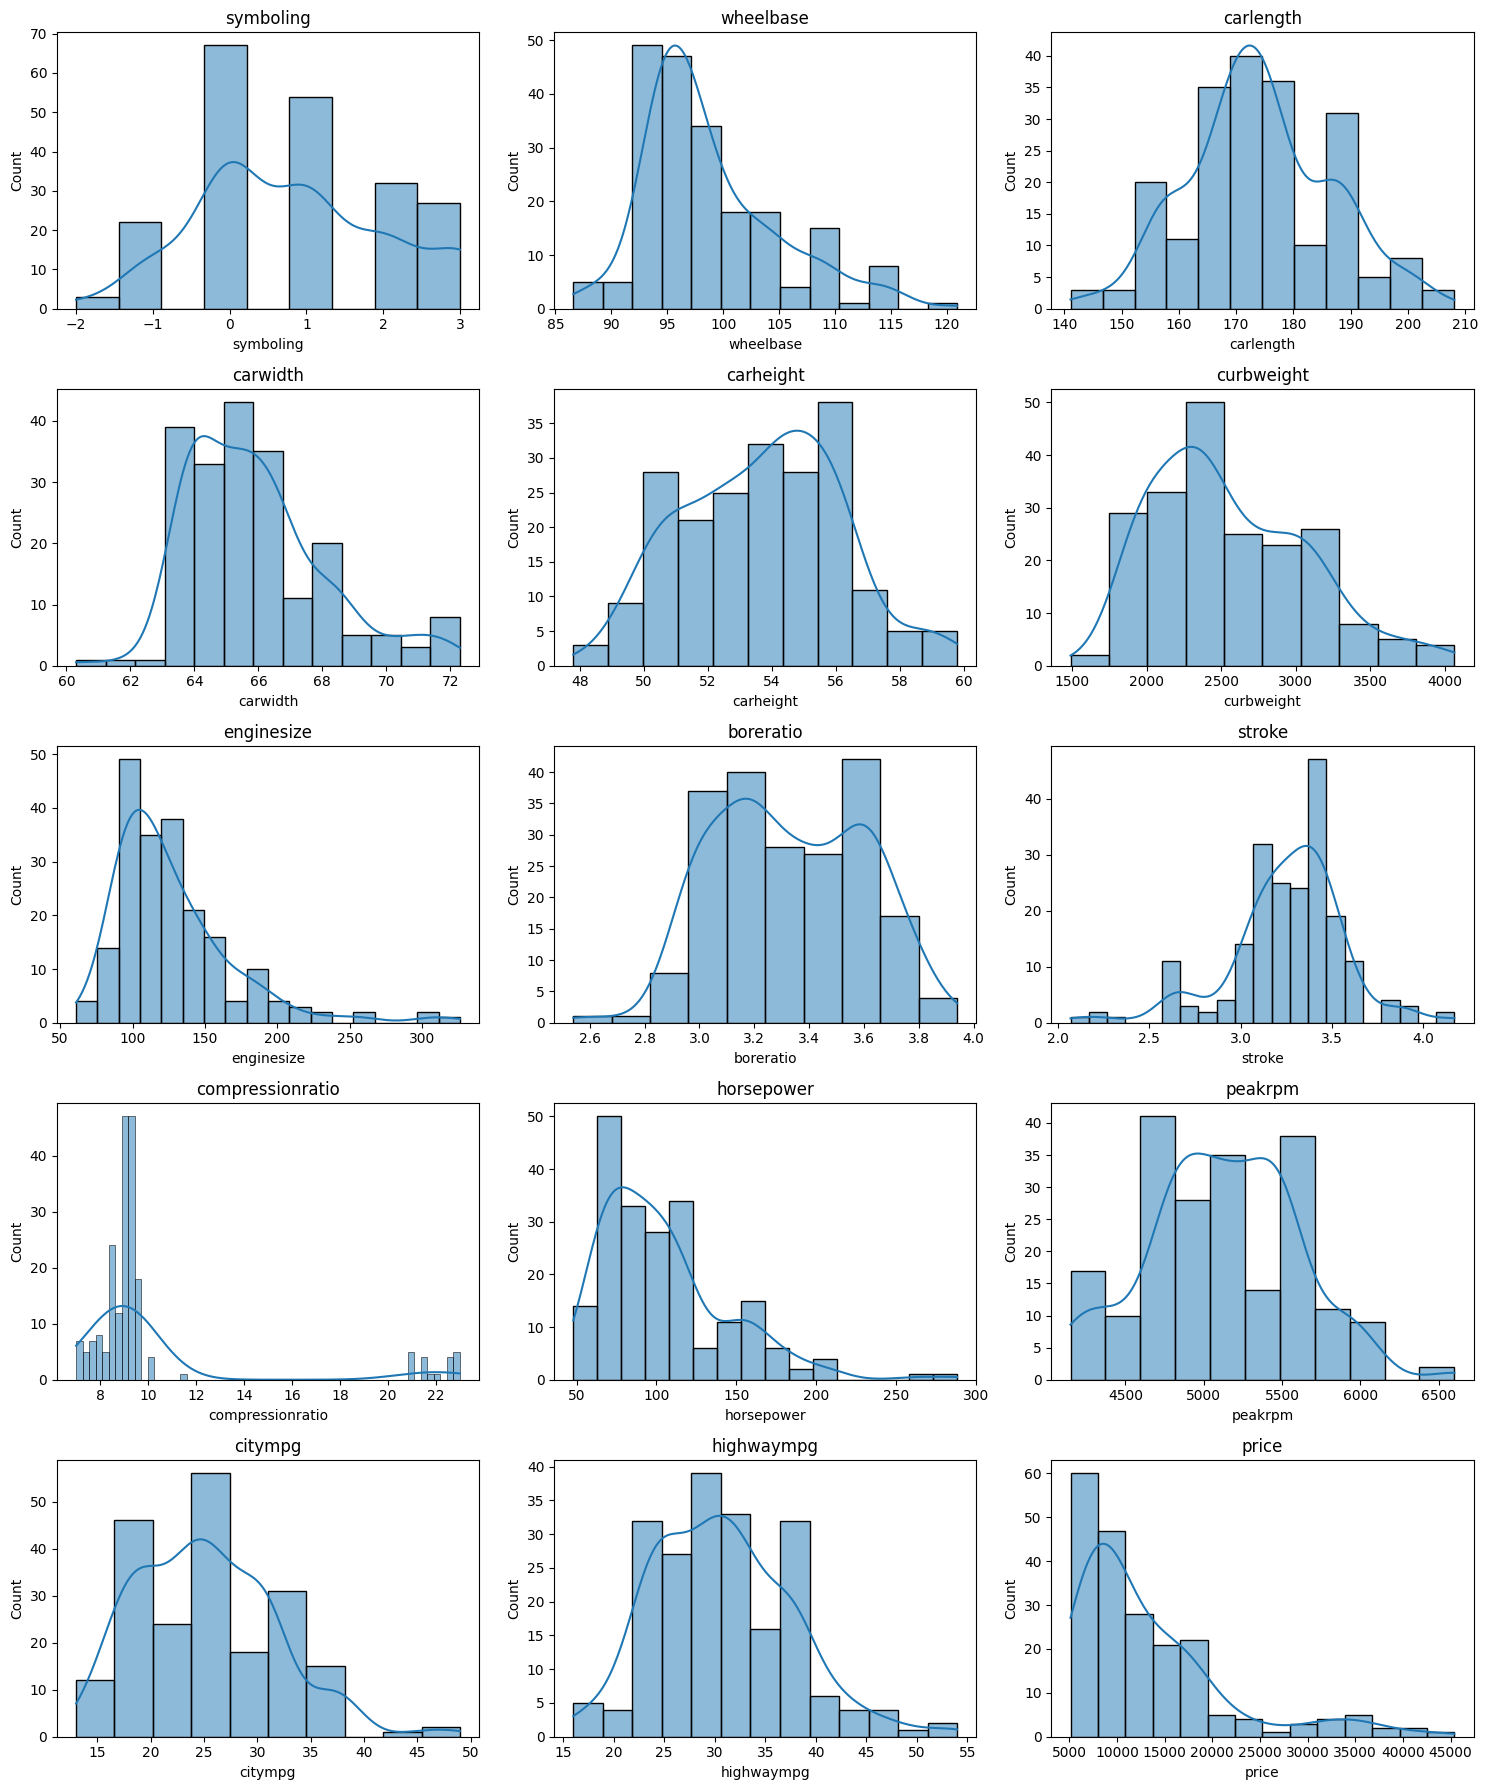

In [59]:
numeric_initial = df_model.select_dtypes(include=np.number).columns
skew_initial = df_model[numeric_initial].skew().sort_values(key=np.abs, ascending=False)
display(skew_initial.to_frame("skewnes"))
n_cols = 3
n_rows = int(np.ceil(len(numeric_initial) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.6 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, numeric_initial):
  sns.histplot(df_model[col], kde=True, ax=ax)
  ax.set_title(col)
for ax in axes[len(numeric_initial):]:
  ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [60]:
X = df_model.drop(columns="price")
y = df_model["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)
id_train = ids.loc[X_train.index]
id_test = ids.loc[X_test.index]

print("train:", X_train.shape)
print("test:", X_test.shape)

train: (164, 24)
test: (41, 24)


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [61]:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]
q1 = X_train[continuous_cols].quantile(0.25)
q3 = X_train[continuous_cols].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr
outlier_counts = (
    (X_train[continuous_cols].lt(lower_bounds)) |
    (X_train[continuous_cols].gt(upper_bounds))
).sum().sort_values(ascending=False)
display(outlier_counts.to_frame("potential_outliers_train"))

X_train = X_train.copy()
X_train[continuous_cols] = X_train[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1,
)
X_test[continuous_cols] = X_test[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1,
)

,potential_outliers_train
compressionratio,20
stroke,16
carwidth,10
horsepower,7
enginesize,7
wheelbase,6
peakrpm,2
highwaympg,1
boreratio,1
curbweight,0


## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


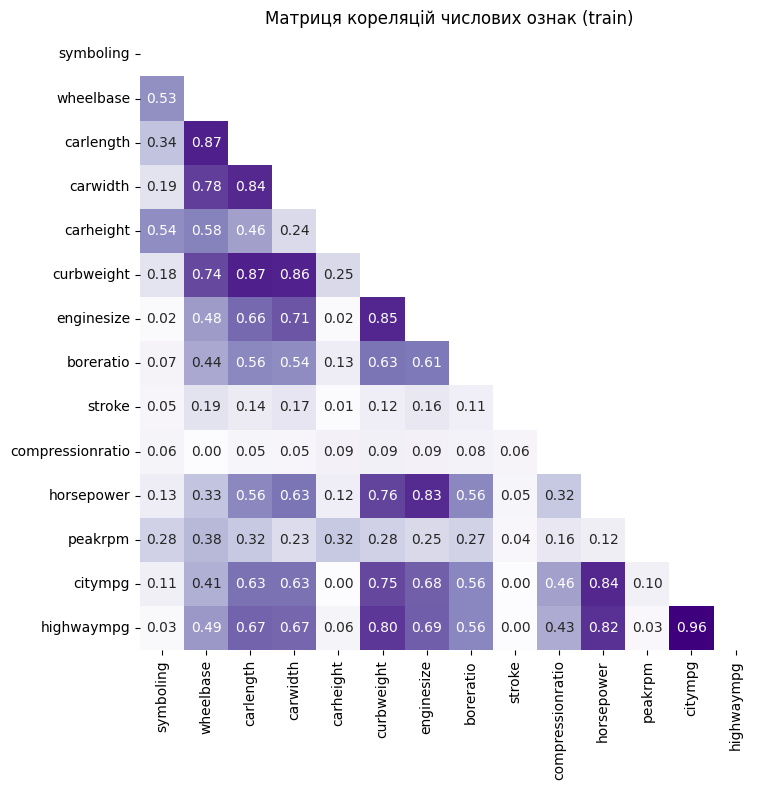

(|r|>0.85):
wheelbase - carlength 0.867
carlength - curbweight 0.866
carwidth - curbweight 0.858
citympg - highwaympg 0.964
: ['carlength', 'carwidth', 'citympg', 'wheelbase']


In [62]:
numeric_train_cols = X_train.select_dtypes(include=np.number).columns
corr = X_train[numeric_train_cols].corr().abs()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    cmap="Purples",
    annot=True,
    fmt=".2f",
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    square=True,
    cbar=False,
)
plt.title("Матриця кореляцій числових ознак (train)")
plt.tight_layout()
plt.show()

target_corr = pd.concat(
    [
        X_train[numeric_train_cols],
        y_train.rename("price")

    ],
    axis=1
).corr(numeric_only=True)["price"].abs()
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
pairs = []
for col in upper.columns:
  for row in upper.index[upper[col] > 0.85]:
    pairs.append((row, col, upper.loc[row, col]))
  features_to_drop = set()
for a, b, r in pairs:
  if target_corr[a] < target_corr[b]:
    features_to_drop.add(a)
  else:
    features_to_drop.add(b)
print("(|r|>0.85):")
for a, b, r in pairs:
  print(f"{a} - {b:} {r:.3f}")
print(":", sorted(features_to_drop))
X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)



## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [75]:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]
ordinal_numeric_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c == "symboling"
]
categorical_cols = (
   X_train
   .select_dtypes(exclude=np.number)
   .columns
   .tolist()
)
numeric_pipeline = Pipeline(steps=(
    ("power",PowerTransformer(
        method="yeo-johnson",
        standardize=False
        )),
         ("scaler",StandardScaler())
)
)
ordinal_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps= [
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", numeric_pipeline, continuous_cols),
        ("ordinal", ordinal_pipeline, ordinal_numeric_cols),
        ("categorical", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
num_check = clone(numeric_pipeline)
num_train_transformed = pd.DataFrame(
    num_check.fit_transform(X_train[continuous_cols]),
    columns=continuous_cols,
    index=X_train.index,
)
skewness_after = (
    num_train_transformed
    .skew()
    .sort_values(key=np.abs, ascending=False)
)
display(
    skewness_after.to_frame("skewness_after")
)

,skewness_after
horsepower,0.066280
curbweight,0.049894
enginesize,0.044834
stroke,0.015846
highwaympg,-0.012188
boreratio,-0.005941
carheight,-0.005170
compressionratio,0.004872
peakrpm,-0.003589


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [76]:
estimators = {
    "Linear Regression": LinearRegression(),
    "Ridge ": Ridge(
        alpha=1.0
    ),
    "Lasso ": Lasso(
        alpha=1.0,
        max_iter=20000
    ),
    "Random Forest ": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting ": GradientBoostingRegressor(
        random_state=42,
    ),
    "Support Vector R": SVR(),
}
models = {
    name: Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])

for name, estimator in estimators.items()
}

## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [77]:
results = []

predictions = {}

for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  predictions[name] = y_pred

  results.append({
      "Model": name,
      "R2": r2_score(y_test, y_pred),
      "MAE": mean_absolute_error(y_test, y_pred),
      "MSE": mean_squared_error(y_test, y_pred),
      "MAPE, %": mean_absolute_percentage_error(y_test, y_pred) * 100,
  })
  results_df = (
      pd.DataFrame(results)
      .sort_values(
          "R2",
          ascending=False
      )
      .reset_index(drop=True)
  )
display(results_df)

,Model,R2,MAE,MSE,"MAPE, %"
0,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
1,Gradient Boosting,0.930420,1727.403684,5.492942e+06,12.050186
2,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
3,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
4,Ridge,0.853789,2367.223583,1.154249e+07,18.193087
5,Support Vector R,-0.099732,5696.776966,8.681724e+07,36.027666


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


/tmp/ipykernel_2895/2228230670.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


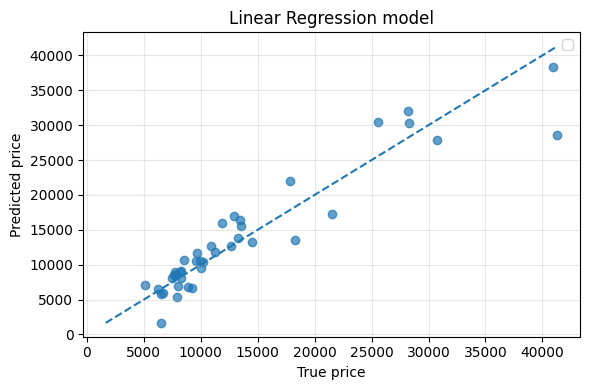

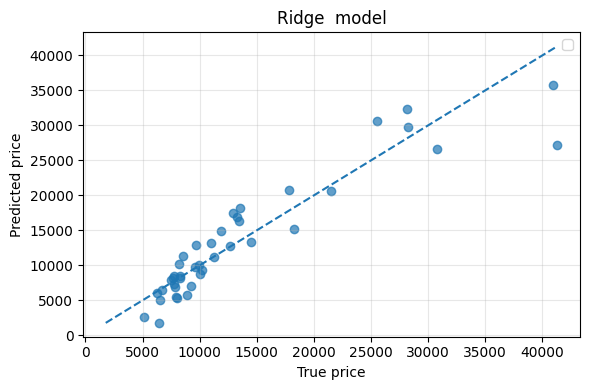

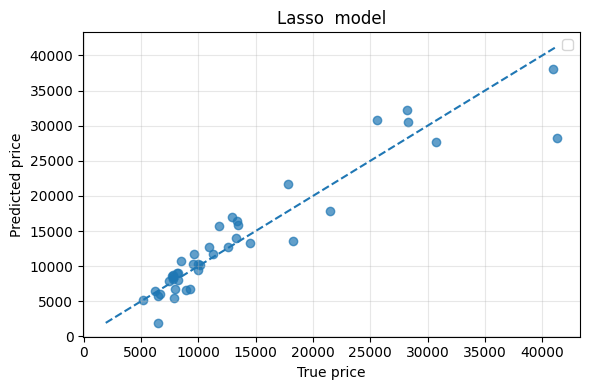

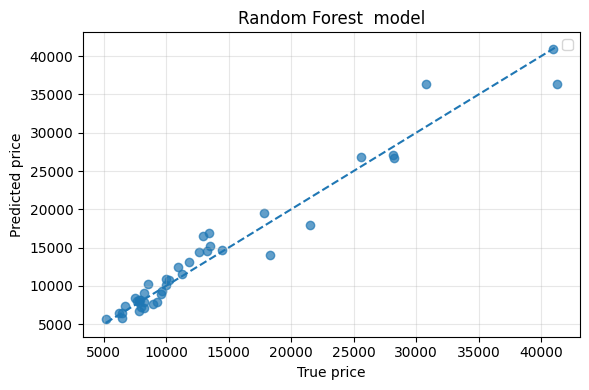

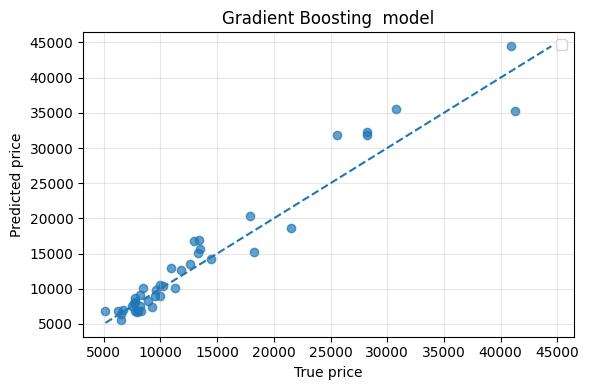

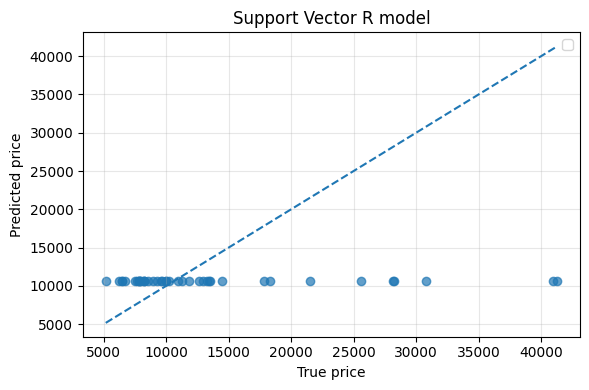

In [80]:
y_true = y_test.to_numpy()
for name, y_pred in predictions.items():
  y_pred = np.asarray(y_pred).ravel()
  lo = min(y_true.min(), y_pred.min())
  hi = max(y_true.max(), y_pred.max())
  plt.figure(figsize=(6, 4))
  plt.scatter(y_true, y_pred, alpha=0.7)
  plt.plot([lo, hi], [lo, hi], "--", label="")
  plt.xlabel("True price")
  plt.ylabel("Predicted price")
  plt.title(f"{name} model")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [85]:
rf_model = models["Random Forest "]
sample_idx = X_test.sample(
    n=min(10, len(X_test)),
    random_state=42
).index
sample_pred = rf_model.predict(
    X_test.loc[sample_idx]
)
sample_rf = pd.DataFrame({
        "car_ID": id_test.loc[sample_idx].to_numpy(),
        "actual_price": y_test.loc[sample_idx].to_numpy(),
        "predicted_price": sample_pred,
})
sample_rf["Absolute error"] = (
    sample_rf["actual_price"] - sample_rf["predicted_price"]
).abs()
sample_rf["Relative percentage error, %"] = (
    sample_rf["Absolute error"] / sample_rf["actual_price"]
    * 100

)
display(sample_rf)

,car_ID,actual_price,predicted_price,Absolute error,"Relative percentage error, %"
0,26,6692.0,7316.599000,624.599000,9.333518
1,176,9988.0,10940.662000,952.662000,9.538066
2,148,10198.0,10797.708167,599.708167,5.880645
3,17,41315.0,36371.429000,4943.571000,11.965560
4,69,28248.0,26661.713000,1586.287000,5.615573
5,147,7463.0,8367.516333,904.516333,12.120010
6,144,9960.0,10117.517667,157.517667,1.581503
7,85,14489.0,14688.636000,199.636000,1.377845
8,195,12940.0,16470.556000,3530.556000,27.284049
9,160,7788.0,7907.148000,119.148000,1.529892


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


# У ході роботи було проведено аналіз датасету автомобілів та підготовлено дані для машинного навчання. Було виконано аналіз кореляцій між числовими ознаками, видалено сильно корельовані ознаки та виконано масштабування й кодування даних. Для прогнозування ціни автомобіля було побудовано та порівняно кілька моделей: Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting та SVR. Якість моделей оцінювалася за метриками R², MAE, MSE та MAPE. Отримані результати дозволяють визначити модель, яка найкраще підходить для прогнозування вартості автомобілів.

## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
